In [1]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 10

datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "raw-img",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "raw-img",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("\n✅ Data loaded!")
print("🐾 Classes:", train_data.class_indices)

Found 20947 images belonging to 10 classes.
Found 5232 images belonging to 10 classes.

✅ Data loaded!
🐾 Classes: {'butterfly': 0, 'cat': 1, 'chicken': 2, 'cow': 3, 'dog': 4, 'elephant': 5, 'horse': 6, 'sheep': 7, 'spider': 8, 'squirrel': 9}


In [2]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Pretrained model load karo
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze karo
base_model.trainable = False

# Apne layers add karo
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Compile karo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model ready!")
model.summary()

✅ Model ready!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [3]:
print("🚀 Training shuru ho rahi hai...")
print("⏳ 20 epochs chalenge - thoda wait karo!\n")

history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    verbose=1
)

print("\n🎉 Training complete!")

🚀 Training shuru ho rahi hai...
⏳ 20 epochs chalenge - thoda wait karo!

Epoch 1/20
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 937s 444ms/step - accuracy: 0.8853 - loss: 0.3660 - val_accuracy: 0.9369 - val_loss: 0.2041
Epoch 2/20
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 697s 332ms/step - accuracy: 0.9194 - loss: 0.2575 - val_accuracy: 0.9337 - val_loss: 0.2031
Epoch 3/20
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 695s 332ms/step - accuracy: 0.9266 - loss: 0.2374 - val_accuracy: 0.9308 - val_loss: 0.2213
Epoch 4/20
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 697s 332ms/step - accuracy: 0.9314 - loss: 0.2197 - val_accuracy: 0.9400 - val_loss: 0.1871
Epoch 5/20
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 698s 333ms/step - accuracy: 0.9326 - loss: 0.2075 - val_accuracy: 0.9333 - val_loss: 0.2014
Epoch 6/20
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 701s 335ms/step - accuracy: 0.9368 - loss: 0.1994 - val_accuracy: 0.9343 - val_loss: 0.2022
Epoch 7/20
2095/2095 ━━━━━━━━━━━━━━━━━━━━ 701s 335ms/step - accuracy: 0.9394 - loss: 0.1936 - val_accuracy: 0.9404 - val_lo

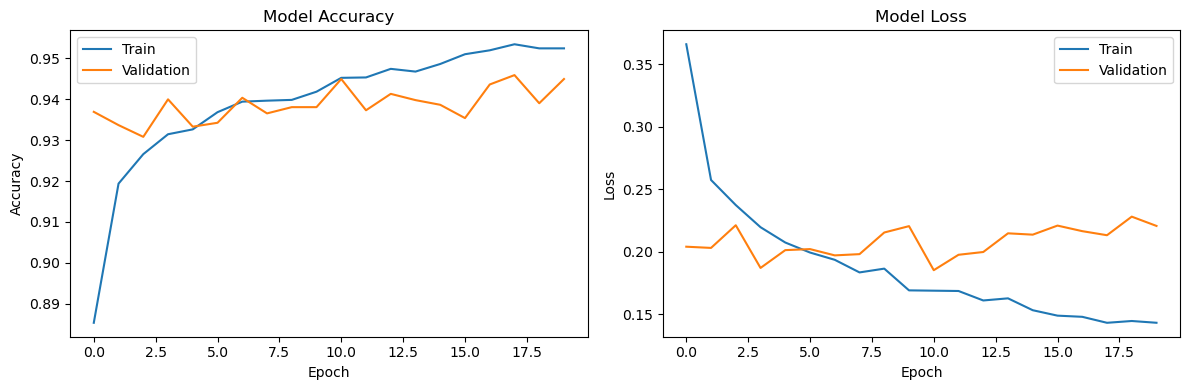

In [4]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
import os

os.makedirs("model", exist_ok=True)
model.save("model/animal_classifier.h5")

print("✅ Model saved successfully!")
print("📁 Location: D:/animal_project/model/")

✅ Model saved successfully!
📁 Location: D:/animal_project/model/


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


C:\Users\ADMIN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


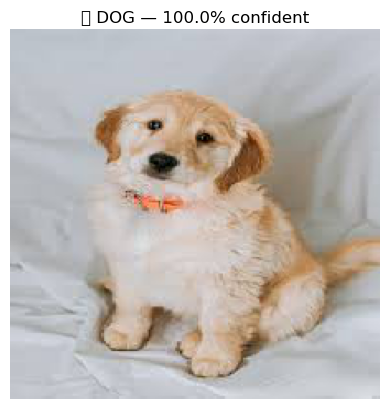

✅ Predicted: dog
📊 Confidence: 100.0%


In [6]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Class names
class_names = ['butterfly', 'cat', 'chicken', 'cow', 
                'dog', 'elephant', 'horse', 'sheep', 
                'spider', 'squirrel']

# Image path — apni image ka path daalo
img_path = "Dog.jpg"  # ← apni image ka naam

# Image load karo
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict karo
predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions)]
confidence = round(100 * np.max(predictions), 2)

# Result dikhao
plt.imshow(img)
plt.title(f"🐾 {predicted_class.upper()} — {confidence}% confident")
plt.axis('off')
plt.show()

print(f"✅ Predicted: {predicted_class}")
print(f"📊 Confidence: {confidence}%")